# Convolutional Neural Networks (CNNs)

**Author:** *Corneliu Catlabuga*

**Group:** *IS-251M*

## Imports

In [ ]:
from keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalMaxPool2D, GlobalAveragePooling2D, Lambda
from keras.applications import ResNet50, InceptionV3
from keras.applications.resnet import preprocess_input
from keras.utils import image_dataset_from_directory
from keras import Sequential
from matplotlib import pyplot as plt
import kagglehub as kh

## Parameters

In [3]:
DATASET = "olafkrastovski/handwritten-digits-0-9"
DOWNLOAD_PATH = f"data/{DATASET}"
INPUT_SHAPE = (224, 224, 3)
EPOCHS = 10
BATCH_SIZE = 32

## Dataset Aquisition

In [7]:
df_path = kh.dataset_download(DATASET, output_dir=DOWNLOAD_PATH)

## Dataset Splitting

In [ ]:
train_ds = image_dataset_from_directory(
    df_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    df_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE
)

Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.


## Model Definition and Compilation

In [8]:
model = Sequential()

model.add(Conv2D(input_shape=INPUT_SHAPE, padding='same', filters=32, kernel_size=(7, 7)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, padding='valid', kernel_size=(5, 5)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Conv2D(filters=256, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(GlobalMaxPool2D())

model.add(Dense(units=256))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(units=10))
model.add(Activation('softmax'))

/home/muffindud/Documents/RNIP/lab2/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 108, 108, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,086,410 (4.14 MB)

 Trainable params: 1,084,938 (4.14 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1777732993.613619    4186 service.cc:153] XLA service 0x7d31040517f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777732993.613643    4186 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777732993.673938    4186 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777732994.076076    4186 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777732994.204141    4186 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5233__.84


  2/539 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.1172 - loss: 11.7074   

I0000 00:00:1777733006.029657    4186 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


537/539 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4415 - loss: 2.4096

I0000 00:00:1777733033.590291    4184 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5233__.84


539/539 ━━━━━━━━━━━━━━━━━━━━ 62s 86ms/step - accuracy: 0.6622 - loss: 1.1935 - val_accuracy: 0.8815 - val_loss: 0.4968
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.9169 - loss: 0.2585 - val_accuracy: 0.9065 - val_loss: 0.3305
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.9463 - loss: 0.1734 - val_accuracy: 0.7145 - val_loss: 0.7991
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9587 - loss: 0.1332 - val_accuracy: 0.6980 - val_loss: 0.8973
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.9670 - loss: 0.1037 - val_accuracy: 0.4718 - val_loss: 1.8409
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9672 - loss: 0.1020 - val_accuracy: 0.4769 - val_loss: 1.9061
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9703 - loss: 0.0929 - val_accuracy: 0.3278 - val_loss: 2.6880
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.9721 - loss: 0.0950 - val_accurac

## Dataset Evaluation

Evaluating model...
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9763 - loss: 0.0786
Validation Loss: 0.0786
Validation Accuracy: 0.9763


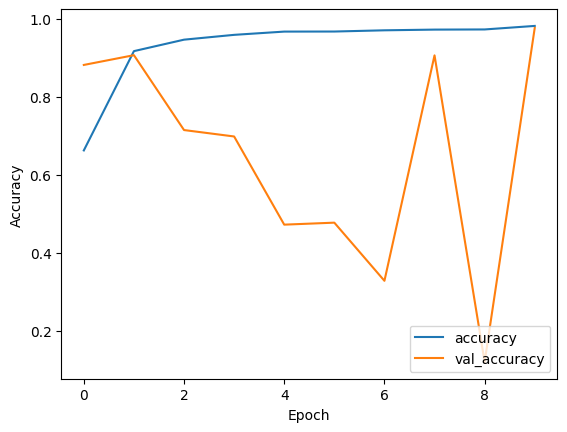

In [11]:
print("Evaluating model...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
model.save('models/handwritten_digits_model.keras')

## ResNet50

In [4]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

base_model.trainable = False

resnet_model = Sequential([
    base_model,
    GlobalMaxPool2D(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

resnet_model.summary()

W0000 00:00:1778056828.946875   20788 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778056828.951553   20788 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778056829.075400   20788 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5220 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1778056952.195241   21990 service.cc:153] XLA service 0x7ca654068190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778056952.195267   21990 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778056952.300830   21990 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778056953.522611   21990 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778056953.593109   21990 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11239__.182


  3/539 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.1597 - loss: 11.7358   

I0000 00:00:1778056960.689395   21990 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


537/539 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7361 - loss: 1.5753

I0000 00:00:1778056980.342085   21992 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11239__.182


539/539 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.8533 - loss: 0.6013 - val_accuracy: 0.9455 - val_loss: 0.1602
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9434 - loss: 0.1745 - val_accuracy: 0.9571 - val_loss: 0.1321
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9538 - loss: 0.1360 - val_accuracy: 0.9717 - val_loss: 0.0906
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9654 - loss: 0.1027 - val_accuracy: 0.9492 - val_loss: 0.1667
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9647 - loss: 0.0996 - val_accuracy: 0.9664 - val_loss: 0.1117
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9684 - loss: 0.0912 - val_accuracy: 0.9601 - val_loss: 0.1284
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9716 - loss: 0.0893 - val_accuracy: 0.9770 - val_loss: 0.0792
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9760 - loss: 0.0727 - val_accurac

Evaluating ResNet model...
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9761 - loss: 0.0769
Validation Loss: 0.0769
Validation Accuracy: 0.9761


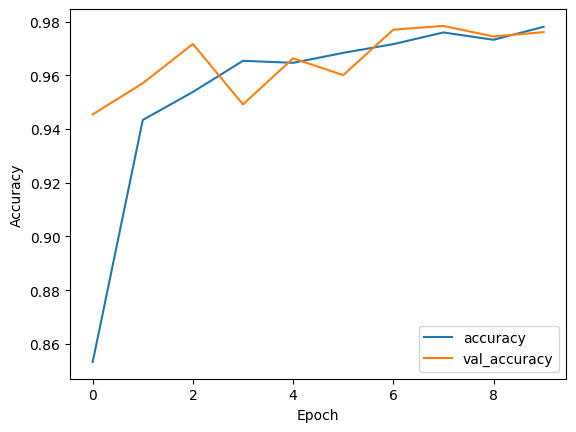

In [11]:
print("Evaluating ResNet model...")

loss, accuracy = resnet_model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [13]:
# Save the model
resnet_model.save('models/handwritten_digits_model_resnet.keras')

## InceptionV3

In [41]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

base_model.trainable = False

inception_model = Sequential([
    Lambda(preprocess_input, input_shape=INPUT_SHAPE),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

inception_model.summary()

/home/muffindud/Documents/RNIP/lab2/venv/lib/python3.12/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,898 (85.18 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [42]:
inception_model.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1778059103.928227   21993 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_220937__.213


538/539 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1622 - loss: 5.8201

I0000 00:00:1778059122.695270   21991 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_220937__.213


539/539 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.1573 - loss: 3.0183 - val_accuracy: 0.1434 - val_loss: 2.2416
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.2157 - loss: 2.0554 - val_accuracy: 0.3062 - val_loss: 1.8748
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.2579 - loss: 1.9398 - val_accuracy: 0.3299 - val_loss: 1.7657
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.3243 - loss: 1.8155 - val_accuracy: 0.4280 - val_loss: 1.6726
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.3708 - loss: 1.7302 - val_accuracy: 0.4175 - val_loss: 1.6388
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.3776 - loss: 1.7231 - val_accuracy: 0.5208 - val_loss: 1.4555
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.4056 - loss: 1.6558 - val_accuracy: 0.4918 - val_loss: 1.4879
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.4152 - loss: 1.6452 - val_accurac

Evaluating InceptionV3 model...
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5488 - loss: 1.3676
Validation Loss: 1.3676
Validation Accuracy: 0.5488


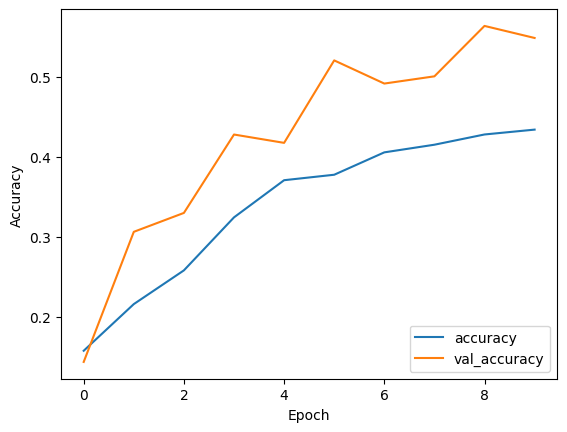

In [44]:
print("Evaluating InceptionV3 model...")

loss, accuracy = inception_model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [45]:
inception_model.save('models/handwritten_digits_model_inception.keras')